Week 4 — Telco Customer Churn (IBM): EDA & Preprocessing

New dataset this week: the IBM Telco Customer Churn dataset. We obtain, explore, and preprocess it for the machine learning algorithms,
and save the processed train/test split and pipeline so Weeks 5 and 6 can load them directly.

Obtain the data

7043 customers, 33 columns. Target is Churn Value (1 = churned, 0 = stayed).
Downloaded from Kaggle (yeanzc/telco-customer-churn-ibm-dataset), a public IBM sample, about 1.25 MB.
These are one-row-per-customer records, not time-series. kagglehub caches the file so re-runs get the same data.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import joblib

RANDOM_STATE = 42

# Where the processed artifacts for Weeks 5 and 6 will be saved.
# Kept in its own folder so it never collides with a teammate's notebook outputs.
PROCESSED_DIR = Path("outputs/week4_updated")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
import kagglehub

# Download latest version (cached locally on re-runs)
path = kagglehub.dataset_download("yeanzc/telco-customer-churn-ibm-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/ducnguyen/.cache/kagglehub/datasets/yeanzc/telco-customer-churn-ibm-dataset/versions/1


In [3]:
import os

# The file is an Excel workbook, not a CSV
df = pd.read_excel(os.path.join(path, "Telco_customer_churn.xlsx"))

print(df.shape)
df.head()

(7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:
# Format fix (does not change the data): Total Charges was read as text.
# Coercing to numeric exposes 11 blank strings, all belonging to 0-tenure (brand-new) customers.
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

blanks = df["Total Charges"].isna()
print("Blank Total Charges:", blanks.sum(), "| their tenure values:", df.loc[blanks, "Tenure Months"].unique())

Blank Total Charges: 11 | their tenure values: [0]


CustomerID and the location fields (Lat Long, Latitude, Longitude, Zip Code, City) identify customers and are dropped before modeling.
Count, Country, and State are constant. Churn Score, Churn Reason, and CLTV are computed from the outcome (leakage), so they are dropped too.
We keep a copy of Churn Score aside as a benchmark, so Week 5 can compare our model against IBM's own churn score.

Explore the data

EDA below uses the full dataset to understand it before modeling.

In [5]:
explore = df.copy()

Type, unique values, percent missing, and an example for each column.

In [6]:
summary = pd.DataFrame({
    "dtype": explore.dtypes.astype(str),
    "n_unique": explore.nunique(),
    "pct_missing": (explore.isna().mean() * 100).round(2),
    "example": [explore[c].dropna().iloc[0] if explore[c].notna().any() else None
                for c in explore.columns],
})
summary

,dtype,n_unique,pct_missing,example
CustomerID,str,7043,0.00,3668-QPYBK
Count,int64,1,0.00,1
Country,str,1,0.00,United States
State,str,1,0.00,California
City,str,1129,0.00,Los Angeles
Zip Code,int64,1652,0.00,90003
Lat Long,str,1652,0.00,"33.964131, -118.272783"
Latitude,float64,1652,0.00,33.964131
Longitude,float64,1651,0.00,-118.272783
Gender,str,2,0.00,Male


In [7]:
explore.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,2283.300441,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,2266.771362,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,18.800000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,401.450000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,1397.475000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,3794.737500,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000


Most columns are categorical. Tenure Months, Monthly Charges, and Total Charges are numeric.
Churn Reason is mostly missing (only filled for churners). Total Charges has a few missing values (the 0-tenure customers). Count, Country, and State have one unique value.

In [8]:
# Target balance (full dataset) — raw counts and proportions
print("Counts:")
print(explore["Churn Value"].value_counts())
print("\nProportions:")
print(explore["Churn Value"].value_counts(normalize=True).round(3))

Counts:
Churn Value
0    5174
1    1869
Name: count, dtype: int64

Proportions:
Churn Value
0    0.735
1    0.265
Name: proportion, dtype: float64


About 26.5% churned and 73.5% stayed. Imbalanced, so we look at precision/recall/F1 (not just accuracy) and use class_weight='balanced' when modeling next week.

Churn rate across the categorical features.

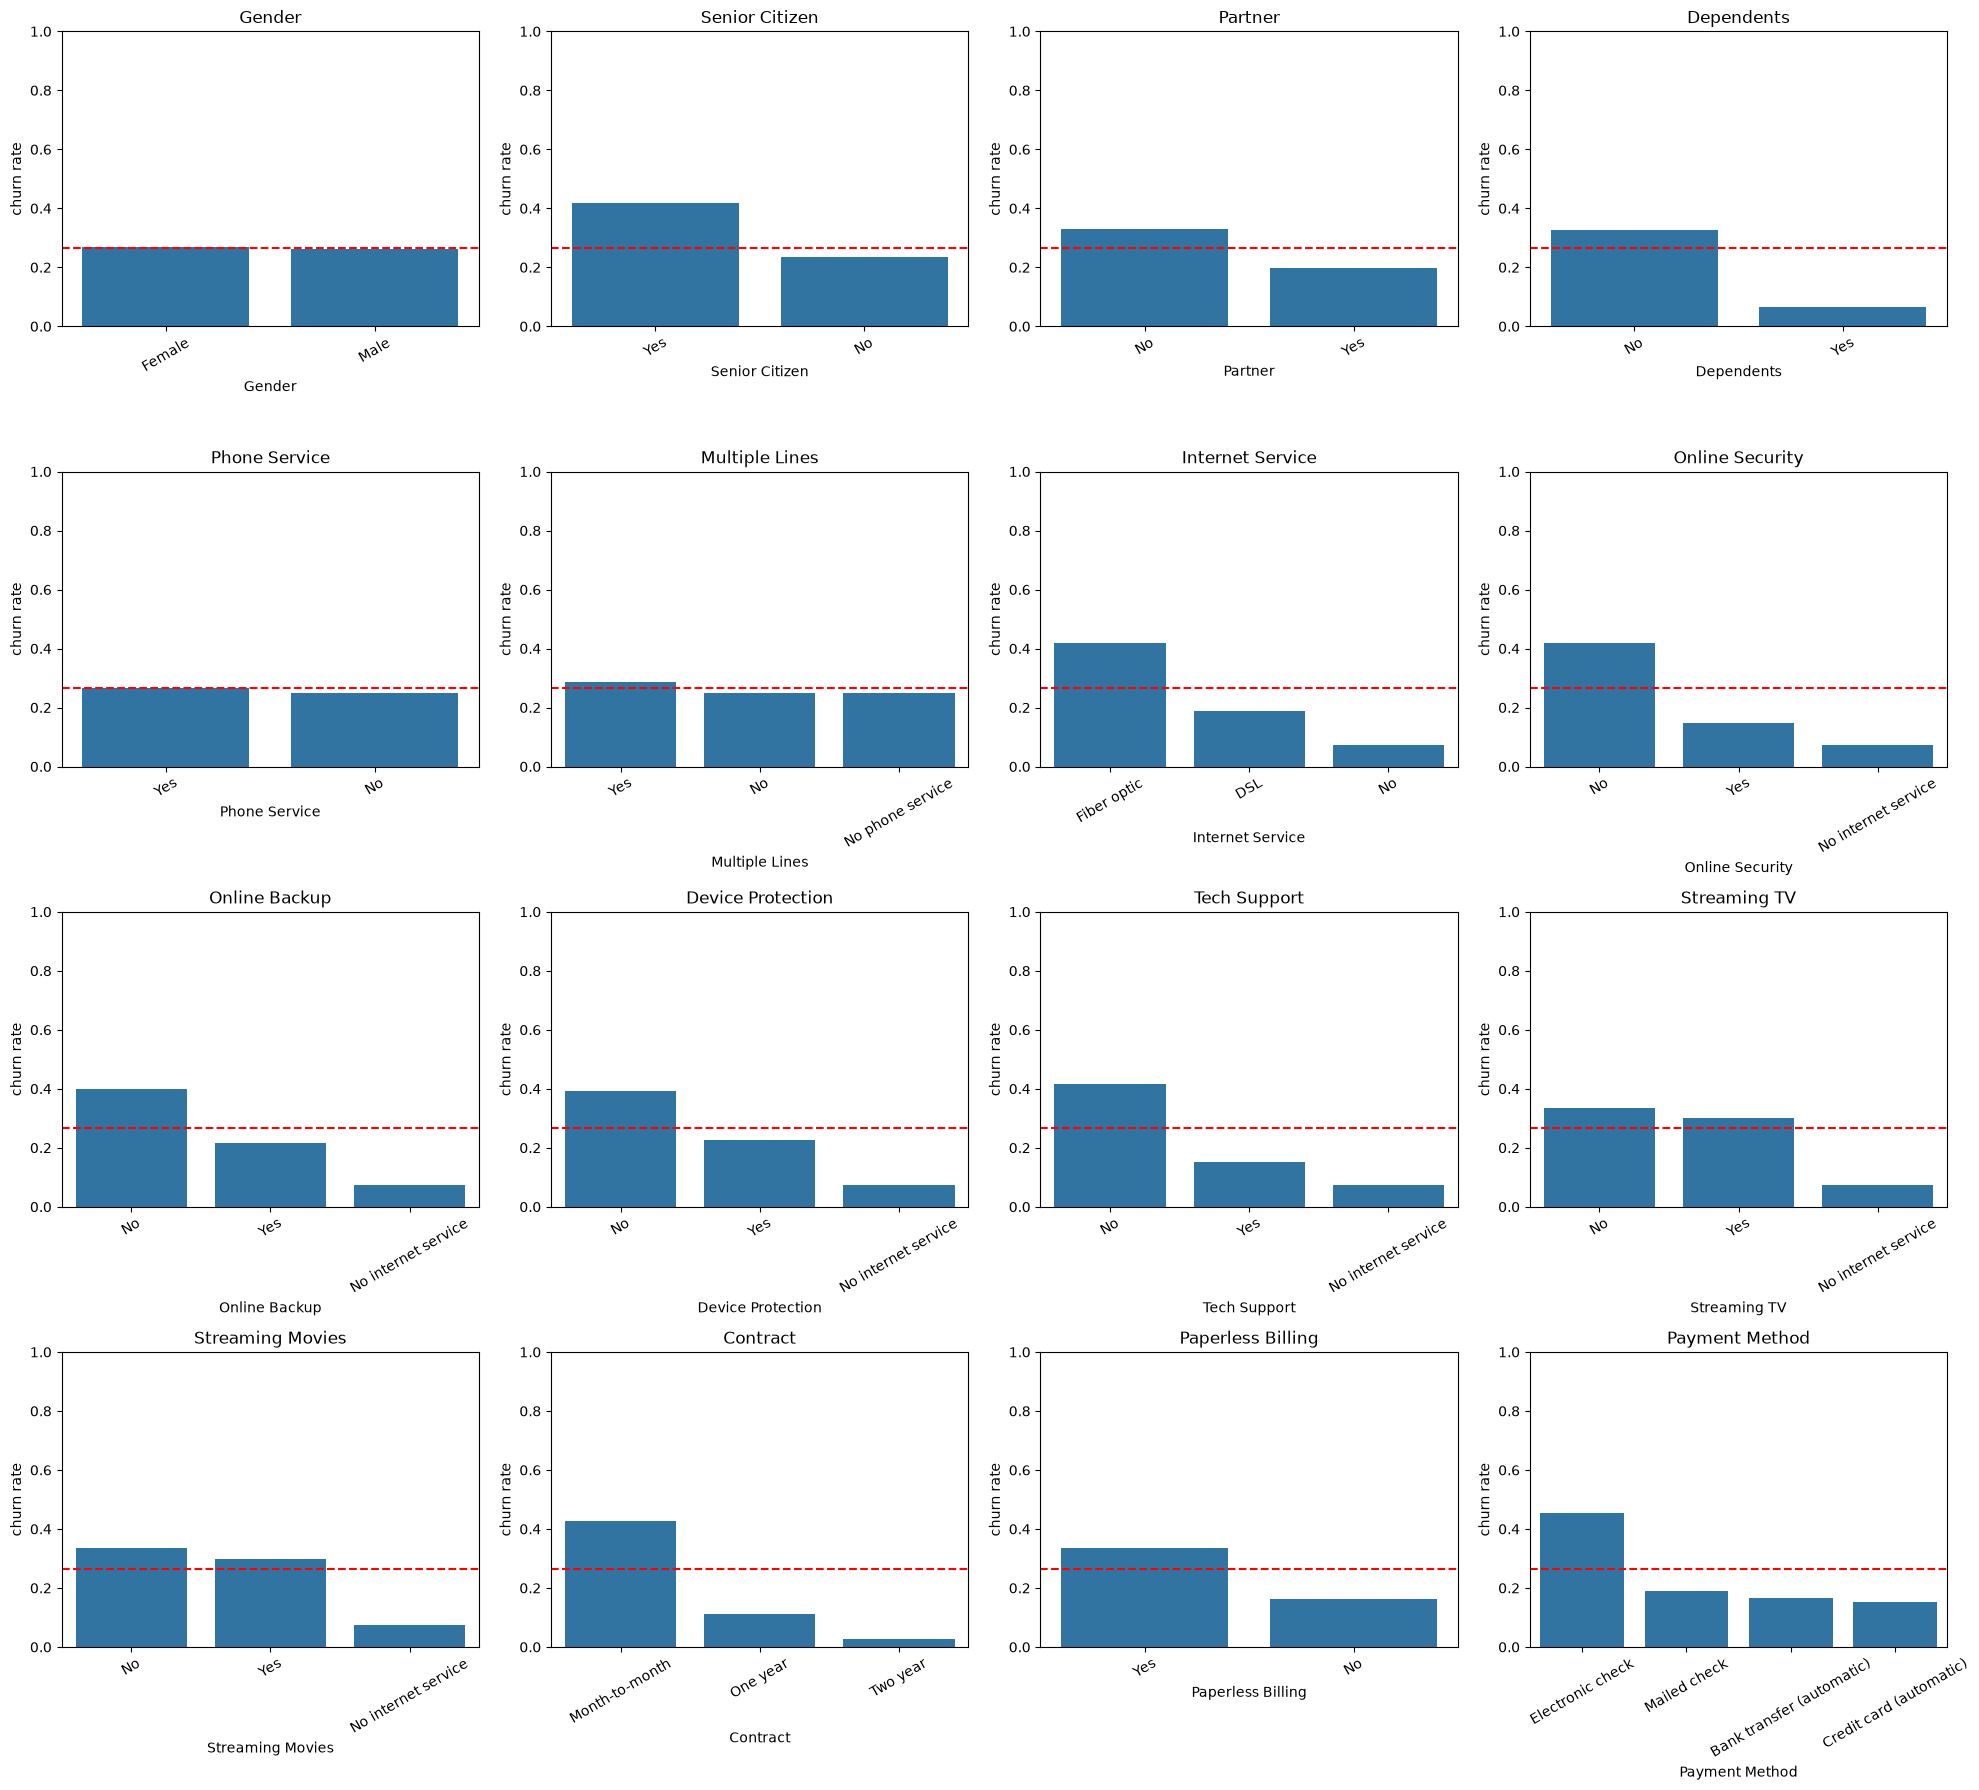

In [9]:
cat_cols = [
    "Gender", "Senior Citizen", "Partner", "Dependents",
    "Phone Service", "Multiple Lines", "Internet Service",
    "Online Security", "Online Backup", "Device Protection",
    "Tech Support", "Streaming TV", "Streaming Movies",
    "Contract", "Paperless Billing", "Payment Method",
]

fig, axes = plt.subplots(4, 4, figsize=(20, 18))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    rate = explore.groupby(col)["Churn Value"].mean().sort_values(ascending=False)
    sns.barplot(x=rate.index, y=rate.values, ax=ax)
    ax.axhline(explore["Churn Value"].mean(), color="red", linestyle="--")
    ax.set_title(col)
    ax.set_ylabel("churn rate")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

Red dashed line is the overall churn rate.
Month-to-month contracts churn the most; one- and two-year contracts rarely churn. Fiber optic customers churn more than DSL. Customers without Online Security, Tech Support, Online Backup, or Device Protection churn more. Electronic check payers churn more than automatic payers. Gender has little effect.

Numeric features and their distributions.

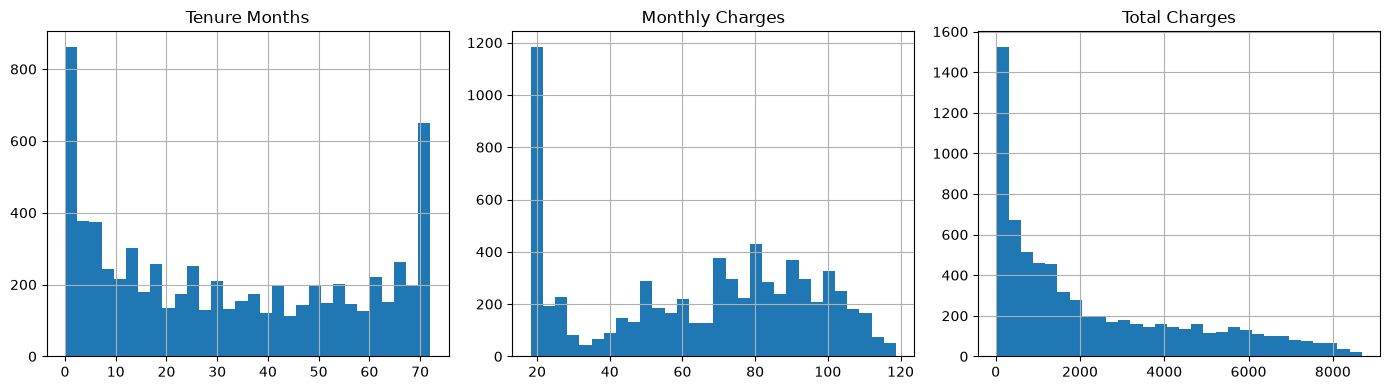

In [10]:
num_cols = ["Tenure Months", "Monthly Charges", "Total Charges"]

explore[num_cols].hist(figsize=(14, 4), bins=30, layout=(1, 3))
plt.tight_layout()
plt.show()

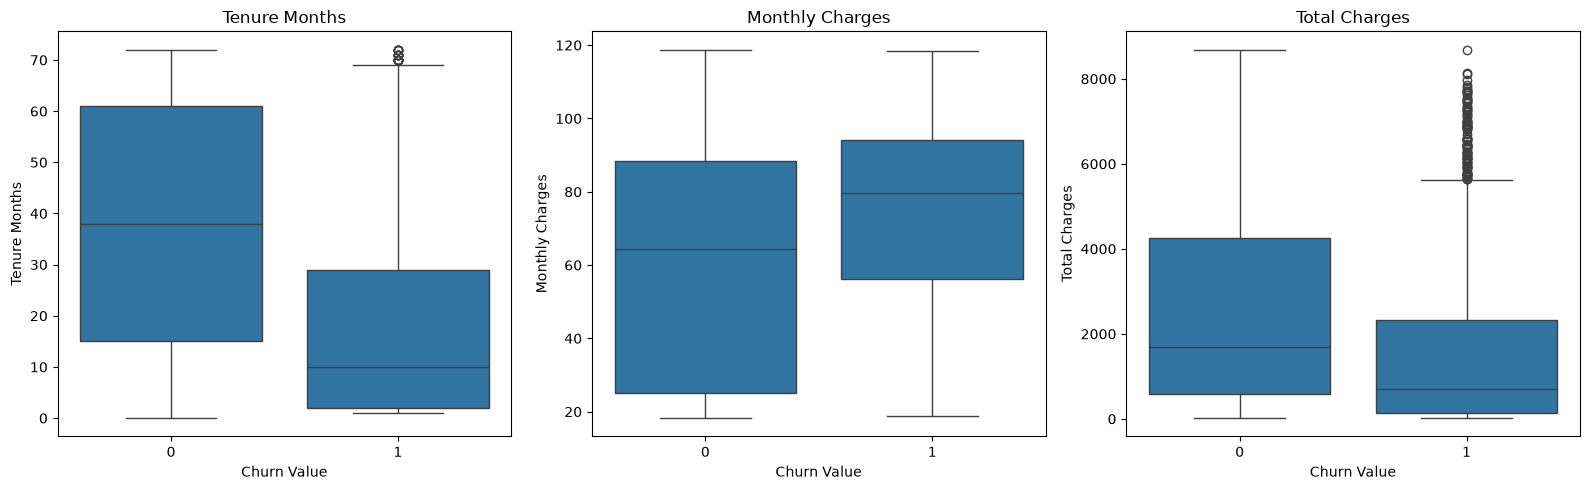

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=explore, x="Churn Value", y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

Tenure is bimodal and churners have lower tenure. Monthly Charges are higher for churners; Total Charges are lower (consistent with leaving early).

The numeric ranges have no impossible values, so there are no outliers to remove. Trimming real customers would only distort the churn signal.

In [12]:
explore[num_cols].agg(["min", "max"]).round(2)

,Tenure Months,Monthly Charges,Total Charges
min,0,18.25,18.8
max,72,118.75,8684.8


Correlations between the numeric attributes.

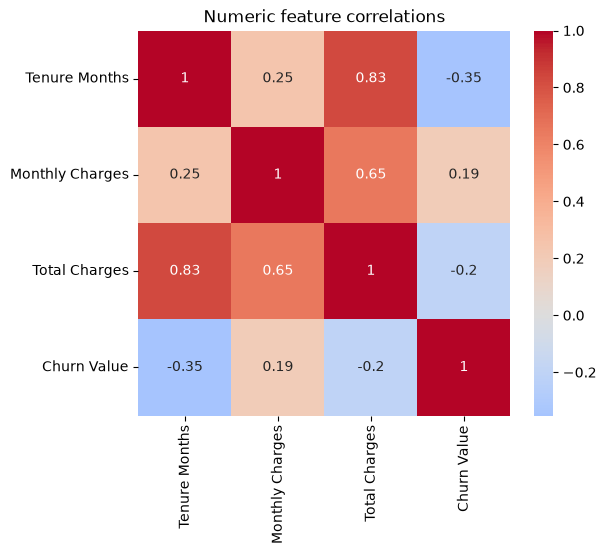

In [13]:
corr = explore[num_cols + ["Churn Value"]].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Numeric feature correlations")
plt.show()

Tenure Months and Total Charges are strongly correlated (0.83) since totals accumulate over time.
Tenure is negatively correlated with churn; Monthly Charges positively. A fuller view comes after encoding, at the end of preparation.

Prepare the data

We write the transformations as functions and a scikit-learn pipeline so the same steps apply to the training set, the test set, and any new data.

In [14]:
# Keep IBM's Churn Score aside as a benchmark for Week 5 (not used as a model feature)
churn_score_benchmark = df["Churn Score"].copy()

# --- Column groups ---
DROP_COLS = [
    "Count", "Country", "State",                                  # constant
    "CustomerID", "City", "Zip Code", "Lat Long",                 # identifier / location
    "Latitude", "Longitude",
    "Churn Label", "Churn Score", "Churn Reason", "CLTV",         # leakage
    "Churn Value",                                                # target (handled separately)
]
ADDON_COLS = ["Online Security", "Online Backup", "Device Protection",
              "Tech Support", "Streaming TV", "Streaming Movies"]

NUMERIC_FEATURES = ["Tenure Months", "Monthly Charges", "Total Charges", "Num_Addon_Services"]
PASSTHROUGH_FEATURES = ["AutoPay", "IsNewCustomer"]   # engineered, already 0/1

In [15]:
def add_features(data):
    """Engineer new features. Returns a new DataFrame (original untouched)."""
    data = data.copy()
    # How many of the 6 optional add-on services the customer subscribes to (0-6)
    data["Num_Addon_Services"] = (data[ADDON_COLS] == "Yes").sum(axis=1)
    # Automatic payment method (bank transfer / credit card) -> churns less
    data["AutoPay"] = data["Payment Method"].str.contains("automatic", case=False).astype(int)
    # Brand-new customers (<= 6 months) -> churn most; concentrates the tenure signal
    data["IsNewCustomer"] = (data["Tenure Months"] <= 6).astype(int)
    return data


def clean_data(data):
    """Fill the one real missing value and drop id/constant/leakage columns."""
    data = data.copy()
    # 0-tenure customers have blank Total Charges; 0 is literally true for them
    data["Total Charges"] = pd.to_numeric(data["Total Charges"], errors="coerce").fillna(0)
    return data.drop(columns=DROP_COLS)


def make_Xy(data):
    """Full raw -> features step for one split; also returns the target."""
    y = data["Churn Value"]
    X = clean_data(add_features(data))
    return X, y

In [16]:
X_all, y_all = make_Xy(df)

print("Features:", X_all.shape)
X_all.head()

Features: (7043, 22)


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Num_Addon_Services,AutoPay,IsNewCustomer
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,2,0,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,0,0,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,3,0,0
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,4,0,0
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,...,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,4,1,0


How the numeric and engineered features relate to churn (full dataset). IsNewCustomer is the strongest of the engineered ones;
AutoPay and Num_Addon_Services are negative, so more engaged / auto-paying customers churn less.

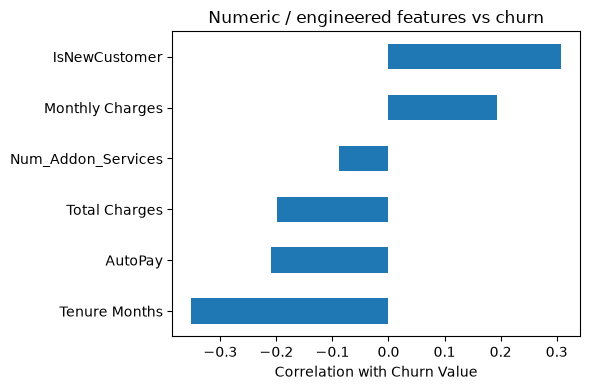

Tenure Months        -0.352
AutoPay              -0.210
Total Charges        -0.198
Num_Addon_Services   -0.088
Monthly Charges       0.193
IsNewCustomer         0.309
Name: Churn Value, dtype: float64

In [17]:
engineered = ["Num_Addon_Services", "AutoPay", "IsNewCustomer",
              "Tenure Months", "Monthly Charges", "Total Charges"]
corr_eng = (
    X_all[engineered].assign(**{"Churn Value": y_all.values})
      .corr()["Churn Value"].drop("Churn Value").sort_values()
)

fig, ax = plt.subplots(figsize=(6, 4))
corr_eng.plot(kind="barh", ax=ax)
ax.set_xlabel("Correlation with Churn Value")
ax.set_title("Numeric / engineered features vs churn")
plt.tight_layout()
plt.show()
corr_eng.round(3)

Train/test split

80/20 split stratified on the target so both sides keep the 26.5/73.5 balance. random_state fixes the split so it is identical across the team's machines.

In [18]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=RANDOM_STATE, stratify=y_all
)

print("Train:", X_train_raw.shape, "churn rate", round(y_train.mean(), 4))
print("Test: ", X_test_raw.shape, "churn rate", round(y_test.mean(), 4))

Train: (5634, 22) churn rate 0.2654
Test:  (1409, 22) churn rate 0.2654


One-hot encode the multi-category columns, scale the numeric ones, and pass the already-0/1 engineered flags through.
Fit on the training set only, then apply the same transform to the test set so no test information leaks in.

In [19]:
categorical_features = [c for c in X_train_raw.columns
                        if c not in NUMERIC_FEATURES + PASSTHROUGH_FEATURES]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), NUMERIC_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False), categorical_features),
    ("bin", "passthrough", PASSTHROUGH_FEATURES),
])

X_train = preprocessor.fit_transform(X_train_raw)   # fit on TRAIN only
X_test  = preprocessor.transform(X_test_raw)         # apply same transform to test

feature_names = preprocessor.get_feature_names_out()
print("Processed shape:", X_train.shape, "->", len(feature_names), "features")
pd.DataFrame(X_train, columns=feature_names).head()

Processed shape: (5634, 43) -> 43 features


,num__Tenure Months,num__Monthly Charges,num__Total Charges,num__Num_Addon_Services,cat__Gender_Male,cat__Senior Citizen_Yes,cat__Partner_Yes,cat__Dependents_Yes,cat__Phone Service_Yes,cat__Multiple Lines_No,...,cat__Contract_Month-to-month,cat__Contract_One year,cat__Contract_Two year,cat__Paperless Billing_Yes,cat__Payment Method_Bank transfer (automatic),cat__Payment Method_Credit card (automatic),cat__Payment Method_Electronic check,cat__Payment Method_Mailed check,bin__AutoPay,bin__IsNewCustomer
0,0.102371,-0.521976,-0.262257,0.507935,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,-0.711743,0.337478,-0.503635,-0.570530,1.0,0.0,1.0,1.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,-0.793155,-0.809013,-0.749883,0.507935,1.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,-0.263980,0.284384,-0.172722,1.047168,0.0,0.0,1.0,0.0,1.0,1.0,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
4,-1.281624,-0.676279,-0.989374,-1.109762,1.0,0.0,1.0,1.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


Sanity checks: no missing values slipped through, train and test have the same encoded width, and the churn balance held on both sides.

In [20]:
assert not np.isnan(X_train).any(), "NaNs in processed train set"
assert not np.isnan(X_test).any(), "NaNs in processed test set"
assert X_train.shape[1] == X_test.shape[1] == len(feature_names)
print("All checks passed.")
print("Train churn rate:", round(y_train.mean(), 4), "| Test churn rate:", round(y_test.mean(), 4))

All checks passed.
Train churn rate: 0.2654 | Test churn rate: 0.2654


What correlates with churn once everything is numeric (training set).

In [21]:
corr_to_churn = (
    pd.DataFrame(X_train, columns=feature_names, index=X_train_raw.index)
      .assign(**{"Churn Value": y_train.values})
      .corr(numeric_only=True)["Churn Value"]
      .drop("Churn Value")
      .sort_values(key=abs, ascending=False)
)
corr_to_churn.head(15)

cat__Contract_Month-to-month                  0.406401
cat__Online Security_No                       0.346382
num__Tenure Months                           -0.345593
cat__Tech Support_No                          0.339101
cat__Internet Service_Fiber optic             0.312656
cat__Payment Method_Electronic check          0.309214
cat__Contract_Two year                       -0.302209
bin__IsNewCustomer                            0.297846
cat__Online Backup_No                         0.269335
cat__Dependents_Yes                          -0.253959
cat__Device Protection_No                     0.248741
cat__Online Security_No internet service     -0.228929
cat__Streaming Movies_No internet service    -0.228929
cat__Streaming TV_No internet service        -0.228929
cat__Device Protection_No internet service   -0.228929
Name: Churn Value, dtype: float64

Two-year contracts, longer tenure, and more add-on services lower churn; month-to-month contracts, fiber optic, and electronic check raise it. Matches the EDA.

Save the processed split, the fitted pipeline, the feature names, the cleaned table, and the Churn Score benchmark so Weeks 5 and 6 can load them without re-running this notebook.

In [22]:
np.save(PROCESSED_DIR / "X_train.npy", X_train)
np.save(PROCESSED_DIR / "X_test.npy", X_test)
np.save(PROCESSED_DIR / "y_train.npy", y_train.to_numpy())
np.save(PROCESSED_DIR / "y_test.npy", y_test.to_numpy())

joblib.dump(preprocessor, PROCESSED_DIR / "preprocessor.joblib")

with open(PROCESSED_DIR / "feature_names.json", "w") as f:
    json.dump(list(feature_names), f, indent=2)

# Cleaned but not-yet-encoded table (features + target), for reference
cleaned = clean_data(add_features(df))
cleaned["Churn Value"] = df["Churn Value"].values
cleaned.to_csv(PROCESSED_DIR / "telco_cleaned.csv", index=False)

# Churn Score benchmark aligned to the same train/test rows
np.save(PROCESSED_DIR / "churn_score_train.npy", churn_score_benchmark.loc[X_train_raw.index].to_numpy())
np.save(PROCESSED_DIR / "churn_score_test.npy",  churn_score_benchmark.loc[X_test_raw.index].to_numpy())

print("Saved to", PROCESSED_DIR.resolve())
print(sorted(p.name for p in PROCESSED_DIR.iterdir()))

Saved to /Users/ducnguyen/Desktop/AIT506-Team/outputs/week4_updated
['X_test.npy', 'X_train.npy', 'churn_score_test.npy', 'churn_score_train.npy', 'feature_names.json', 'preprocessor.joblib', 'telco_cleaned.csv', 'y_test.npy', 'y_train.npy']


Done. The data is obtained, explored, and prepared through reusable functions plus a fitted pipeline:
missing values filled, leakage and identifier columns removed, three features engineered, categoricals encoded, and numeric features scaled.
X_train, X_test, y_train, y_test and preprocessor are saved for the modeling in Weeks 5 and 6.